In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

from scipy.stats import pearsonr

In [2]:
# ============================================
# CELL 2: Download VADER Lexicon
# ============================================

# Download the VADER sentiment lexicon
# This only needs to be run once

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
# Load the financial news dataset into a DataFrame

news_df = pd.read_csv('../data/raw_analyst_ratings.csv')

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
# Check:
# - column names
# - datatypes
# - missing values

news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [5]:
# Convert the date column to datetime format
# utc=True ensures timezone consistency
# format='mixed' handles mixed datetime formats

news_df['date'] = pd.to_datetime(
    news_df['date'],
    utc=True,
    format='mixed'
)

In [6]:
# Extract only the date portion
# This helps align news with stock trading days

news_df['trading_date'] = news_df['date'].dt.date

In [7]:
# Create VADER sentiment analyzer object

sia = SentimentIntensityAnalyzer()

In [8]:
# Calculate sentiment scores for each headline
# We use the compound score because it summarizes
# overall sentiment between -1 and +1

news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [9]:
# Display headlines with their sentiment scores

news_df[['headline', 'sentiment_score']].head()

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


In [10]:
# Group by stock and trading date
# Compute average sentiment score per day

daily_sentiment = news_df.groupby(
    ['stock', 'trading_date']
)['sentiment_score'].mean().reset_index()

In [11]:
daily_sentiment.head()

,stock,trading_date,sentiment_score
0,A,2009-04-29,0.0000
1,A,2009-06-01,0.2960
2,A,2009-07-14,0.3818
3,A,2009-07-30,0.0000
4,A,2009-08-04,0.0000


In [12]:
# Load Apple stock data

stock_df = pd.read_csv('../data/AAPL.csv')

In [13]:
# Convert Date column into datetime format

stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [14]:
# Compute percentage daily return using:
# (Close_t - Close_t-1) / Close_t-1 * 100

stock_df['Daily_Return'] = (
    stock_df['Close'].pct_change()
) * 100

In [15]:
# Extract only date portion for merging

stock_df['trading_date'] = stock_df['Date'].dt.date

In [16]:
# Select only Apple-related news

aapl_news = daily_sentiment[
    daily_sentiment['stock'] == 'AAPL'
]

In [17]:
# Merge sentiment data with stock returns
# using trading_date

merged_df = pd.merge(
    aapl_news,
    stock_df[['trading_date', 'Daily_Return']],
    on='trading_date',
    how='inner'
)

In [18]:
# Display merged sentiment and return data

merged_df.head()

,stock,trading_date,sentiment_score,Daily_Return
0,AAPL,2020-03-09,-0.302067,-7.909217
1,AAPL,2020-03-10,-0.090787,7.202157
2,AAPL,2020-03-11,-0.023850,-3.473025
3,AAPL,2020-03-12,-0.078360,-9.875496
4,AAPL,2020-03-13,-0.059727,11.980808


In [19]:
# Calculate Pearson correlation coefficient
# between sentiment scores and daily returns

correlation, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['Daily_Return']
)

# Print results
print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.08915625547933331
P-value: 0.49442385185994653


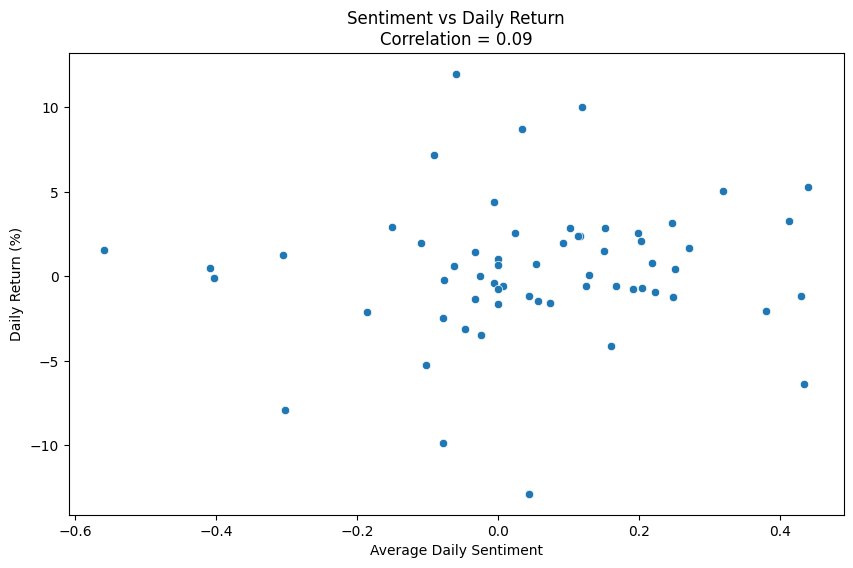

In [20]:

# Visualize relationship between:
# sentiment scores and daily stock returns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x='sentiment_score',
    y='Daily_Return'
)

# Add title with correlation value
plt.title(
    f'Sentiment vs Daily Return\nCorrelation = {correlation:.2f}'
)

# Axis labels
plt.xlabel('Average Daily Sentiment')
plt.ylabel('Daily Return (%)')

# Display plot
plt.show()

In [21]:
# Define function to classify sentiment

def classify_sentiment(score):
    
    # Positive sentiment
    if score > 0.05:
        return 'Positive'
    
    # Negative sentiment
    elif score < -0.05:
        return 'Negative'
    
    # Neutral sentiment
    else:
        return 'Neutral'

In [22]:

# Create sentiment category column

merged_df['sentiment_category'] = merged_df[
    'sentiment_score'
].apply(classify_sentiment)

In [23]:
# Compute average daily return
# for each sentiment category

category_returns = merged_df.groupby(
    'sentiment_category'
)['Daily_Return'].mean().reset_index()

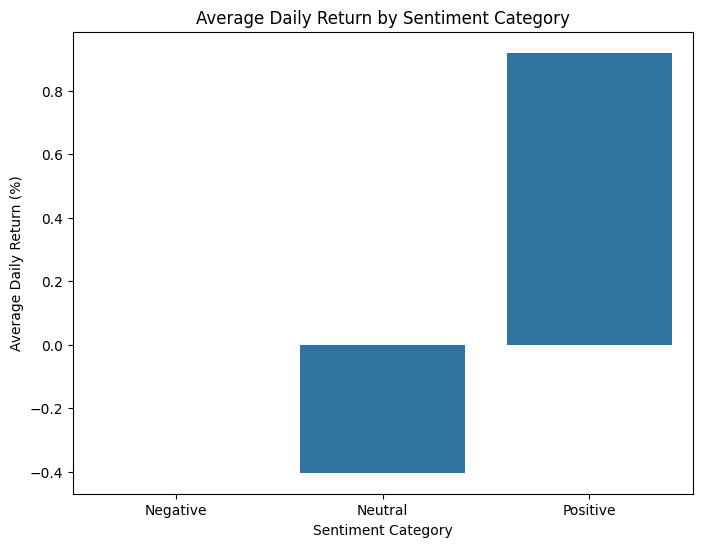

In [24]:
# Visualize average returns by sentiment category

plt.figure(figsize=(8,6))

sns.barplot(
    data=category_returns,
    x='sentiment_category',
    y='Daily_Return'
)

# Add chart title
plt.title('Average Daily Return by Sentiment Category')

# Axis labels
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')

# Display plot
plt.show()

# Interpretation of Results

The correlation analysis measures the statistical relationship between financial news sentiment and daily stock returns.

A positive correlation suggests that more positive news sentiment tends to align with positive stock performance, while a negative correlation would indicate the opposite relationship.

However, the observed relationship may be relatively weak due to market complexity, delayed market reactions, and external factors such as macroeconomic events, investor behavior, and company fundamentals.

Additionally, correlation does not imply causation, and news sentiment alone may not fully explain stock price movements.